# 🎤 INSTRUCTOR — Solutions & Rubric for `03_STUDENT_ai_tasks`
Everything below is **instructor only**. Run all cells for exact numbers.

In [2]:
#@title ▶️ Setup — run this cell first { display-mode: "form" }
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(42)     # fixed seed → everyone sees the same random numbers
print("✅ Setup complete")

✅ Setup complete


## Task 1 · Spam filter — solution

In [4]:
p_spam = 0.40
free_s, free_h = 0.60, 0.05
win_s, win_h = 0.30, 0.02

# Q1
num = free_s * p_spam
den = num + free_h * (1 - p_spam)
print(f"Q1  P(spam | free)           = {num / den:.4f}")

# Q2 (naive Bayes: words independent within each class)
num2 = free_s * win_s * p_spam
den2 = num2 + free_h * win_h * (1 - p_spam)
print(f"Q2  P(spam | free & winner)  = {num2 / den2:.4f}")

# simulation of Q1 and Q2
n = 2_000_000
spam = rng.random(n) < p_spam
free = np.where(spam, rng.random(n) < free_s, rng.random(n) < free_h)
winner = np.where(spam, rng.random(n) < win_s, rng.random(n) < win_h)
print(f"sim Q1 = {spam[free].mean():.4f}    sim Q2 = {spam[free & winner].mean():.4f}")

Q1  P(spam | free)           = 0.8889
Q2  P(spam | free & winner)  = 0.9917
sim Q1 = 0.8889    sim Q2 = 0.9919


**Answers:** Q1 ≈ **0.889** · Q2 ≈ **0.992**.
**Q3:** if the words are positively correlated *within* spam, then seeing "winner" after "free" is less surprising than the independence assumption claims, so naive Bayes **double-counts evidence** and is **over-confident** (the true probability would be lower than 0.992).

**Likely AI traps:** (a) confusing P(free | spam) = 0.6 with P(spam | free); (b) forgetting the ham term in the denominator; (c) multiplying probabilities without noting the independence assumption; (d) giving Q2 by multiplying the two *posteriors*.

## Task 2 · Casino game — solution

E[winnings] = 2.6667   expected profit at price 5 = -2.3333
Var = 12.5556   SD = 3.5434
P(profit) = P(win > 5) = P(roll a 6) = 0.1667    (fair price = 2.6667)


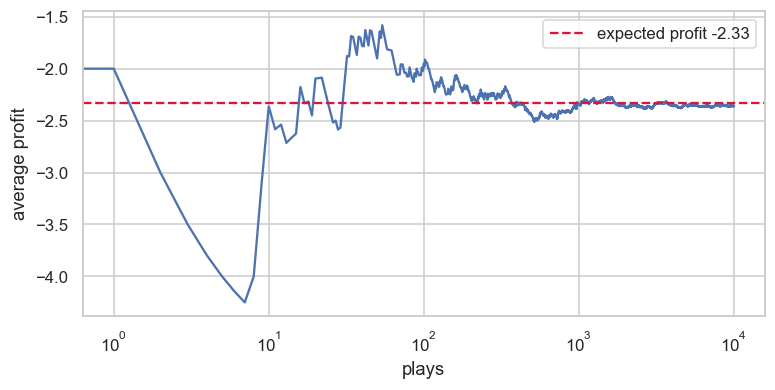

simulated mean profit: -2.361   simulated P(profit): 0.163


In [7]:
x = np.array([10, 3, 0]); p = np.array([1/6, 2/6, 3/6])
E = (x * p).sum(); EX2 = (x**2 * p).sum(); V = EX2 - E**2
print(f"E[winnings] = {E:.4f}   expected profit at price 5 = {E - 5:.4f}")
print(f"Var = {V:.4f}   SD = {np.sqrt(V):.4f}")
print(f"P(profit) = P(win > 5) = P(roll a 6) = {1/6:.4f}    (fair price = {E:.4f})")

rolls = rng.integers(1, 7, 10_000)
win = np.where(rolls == 6, 10, np.where(rolls >= 4, 3, 0))
profit = win - 5
running = np.cumsum(profit) / np.arange(1, 10_001)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(running); ax.axhline(E - 5, color="crimson", ls="--", label=f"expected profit {E - 5:.2f}")
ax.set_xscale("log"); ax.set_xlabel("plays"); ax.set_ylabel("average profit"); ax.legend()
plt.show()
print("simulated mean profit:", profit.mean().round(3), "  simulated P(profit):", (profit > 0).mean().round(3))

**Answers:** E[winnings] = **2.667**, expected profit = **−2.333** per play · Var ≈ **12.56**, SD ≈ **3.54** · P(profit) = **1/6 ≈ 0.167** (only a 6 pays more than ₹5) · fair price ≈ **₹2.67** · running average → **−2.33**.

**Likely AI traps:** (a) forgetting to subtract the ₹5 for "profit"; (b) computing the variance of the *profit* vs the *winnings* — same number, but check they say which; (c) counting a ₹3 win as a "profit" (it's still a loss at ₹5); (d) using 4 and 5 as *one* outcome probability 1/6 instead of 2/6.

## Task 3 · Exam curve — solution

Q1  P(X > 80)        = 0.0668
Q2  P(55 < X < 75)   = 0.6827   (68-95-99.7 rule says ≈0.68)
Q3  A cut-off (top 10%) = 77.82
Q4  z(52) = -1.30   percentile = 9.7%
Q6  P(mean of 25 > 68) = 0.0668
    simulated Q6        = 0.0670
    simulated Q1 / Q3   = 0.0667 / 77.83


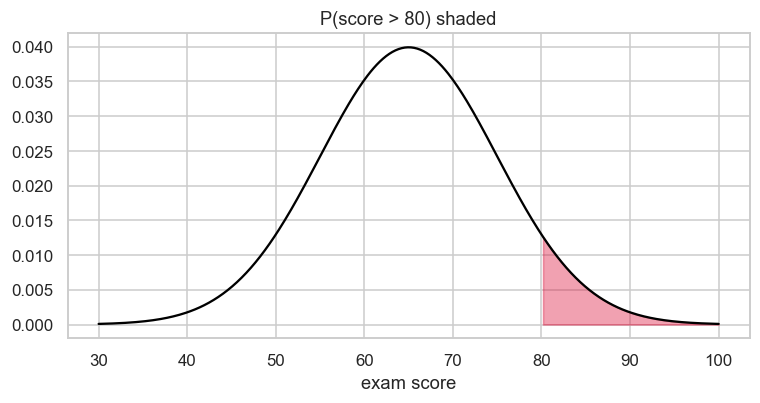

In [10]:
d = stats.norm(65, 10)
print(f"Q1  P(X > 80)        = {1 - d.cdf(80):.4f}")
print(f"Q2  P(55 < X < 75)   = {d.cdf(75) - d.cdf(55):.4f}   (68-95-99.7 rule says ≈0.68)")
print(f"Q3  A cut-off (top 10%) = {d.ppf(0.90):.2f}")
z = (52 - 65) / 10
print(f"Q4  z(52) = {z:.2f}   percentile = {d.cdf(52) * 100:.1f}%")

# Q6: average of 25 students ~ Normal(65, 10/sqrt(25) = 2)
avg = stats.norm(65, 10 / np.sqrt(25))
print(f"Q6  P(mean of 25 > 68) = {1 - avg.cdf(68):.4f}")

sim = rng.normal(65, 10, size=(200_000, 25))
print(f"    simulated Q6        = {(sim.mean(axis=1) > 68).mean():.4f}")
print(f"    simulated Q1 / Q3   = {(sim[:, 0] > 80).mean():.4f} / {np.quantile(sim[:, 0], 0.9):.2f}")

xs = np.linspace(30, 100, 400)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(xs, d.pdf(xs), color="black"); ax.fill_between(xs, d.pdf(xs), where=xs > 80, color="crimson", alpha=0.4)
ax.set_title("P(score > 80) shaded"); ax.set_xlabel("exam score")
plt.show()

**Answers:** Q1 ≈ **0.067** · Q2 ≈ **0.683** (55 and 75 are exactly ±1 SD from the mean, so it matches the 68 % rule; if a student's number differs from 0.68 they probably mixed up σ and σ²) · Q3 ≈ **77.8** · Q4 z = **−1.3**, ≈ **9.7th percentile** · Q6 ≈ **0.067** (average has SD 10/√25 = **2**, so 68 is 1.5 SD above the mean).

**Likely AI traps:** (a) using `norm.ppf(0.10)` instead of 0.90 for "top 10 %"; (b) using SD 10 instead of 2 for the *average* in Q6 (the classic!); (c) writing the 68 % rule answer for Q2 without computing; (d) passing variance instead of standard deviation to `scipy.stats.norm`.

*(Notice Q1 and Q6 give the same ≈0.067 — a coincidence of the numbers: 80 is 1.5 SD above for individuals; 68 is 1.5 SD above for averages. Nice discussion point.)*

---
## 📊 Grading rubric (per task, 100 pts)
| Criterion | 0 | Partial | Full |
|---|---|---|---|
| **Correct answer** (40) | wrong / missing | right method, arithmetic or boundary slip | all numbers correct |
| **Verification** (30) | none or copied AI sim without running | simulation present but doesn't test the stated question | simulation / second method that independently confirms the answer |
| **AI log & judgement** (30) | blank or generic | prompt + answer logged, no critique | names a *specific* place AI could/did go wrong and what they changed |

### 🔎 Spot-check questions for the next class (ask 2–3 students)
* "Show me the prompt you used for Task 3. Did the AI use σ = 10 for the average of 25 students?"
* "How do you know your answer to Task 1 is right if the AI's code had a bug?"
* "What did you change from the AI's answer?" *(if nothing — did you check?)*
* "Which task was AI worst at, and why do you think so?"

### ⚠️ Red flags of un-verified AI use
* Simulation numbers match the exact answer to **every** decimal (probably pasted, not run).
* Log says "AI was correct, no changes" for all three tasks.
* Final answers in the AI's phrasing, not the student's.